NOTEBOOK 3: MODEL TRAINING & COMPARISON

[STEP 1] Loading feature dataset...
✓ Loaded 5011 rows, 53 columns

[STEP 2] Preparing data...
✓ Features shape: (5011, 50)
✓ Target shape: (5011,)
✓ Removed 51 rows with NaN/inf
✓ Final dataset: 4960 rows

[STEP 3] Splitting data (80% train, 20% test)...
✓ Train: 3968 rows
✓ Test: 992 rows

[STEP 4] Scaling features...
✓ Scaler saved

MODEL 1: BASELINE (Last Hour's Price)
[Training...] No training needed (baseline)
✓ Baseline Results:
  MAE:  €27.64
  RMSE: €43.98
  R²:   -0.0326
  MAPE: inf%

MODEL 2: LINEAR REGRESSION
[Training...] Fitting Linear Regression...
✓ Results:
  MAE:  €40.08
  RMSE: €56.27
  R²:   -0.6909
  MAPE: inf%
  Improvement vs Baseline: -45.0%
✓ Model saved

MODEL 3: RANDOM FOREST REGRESSOR
[Training...] Training Random Forest (may take 1-2 min)...
✓ Results:
  MAE:  €23.55
  RMSE: €36.10
  R²:   0.3041
  MAPE: inf%
  Improvement vs Baseline: 14.8%

Top 5 Important Features:
  price_lag_1                   : 0.2975
  price_

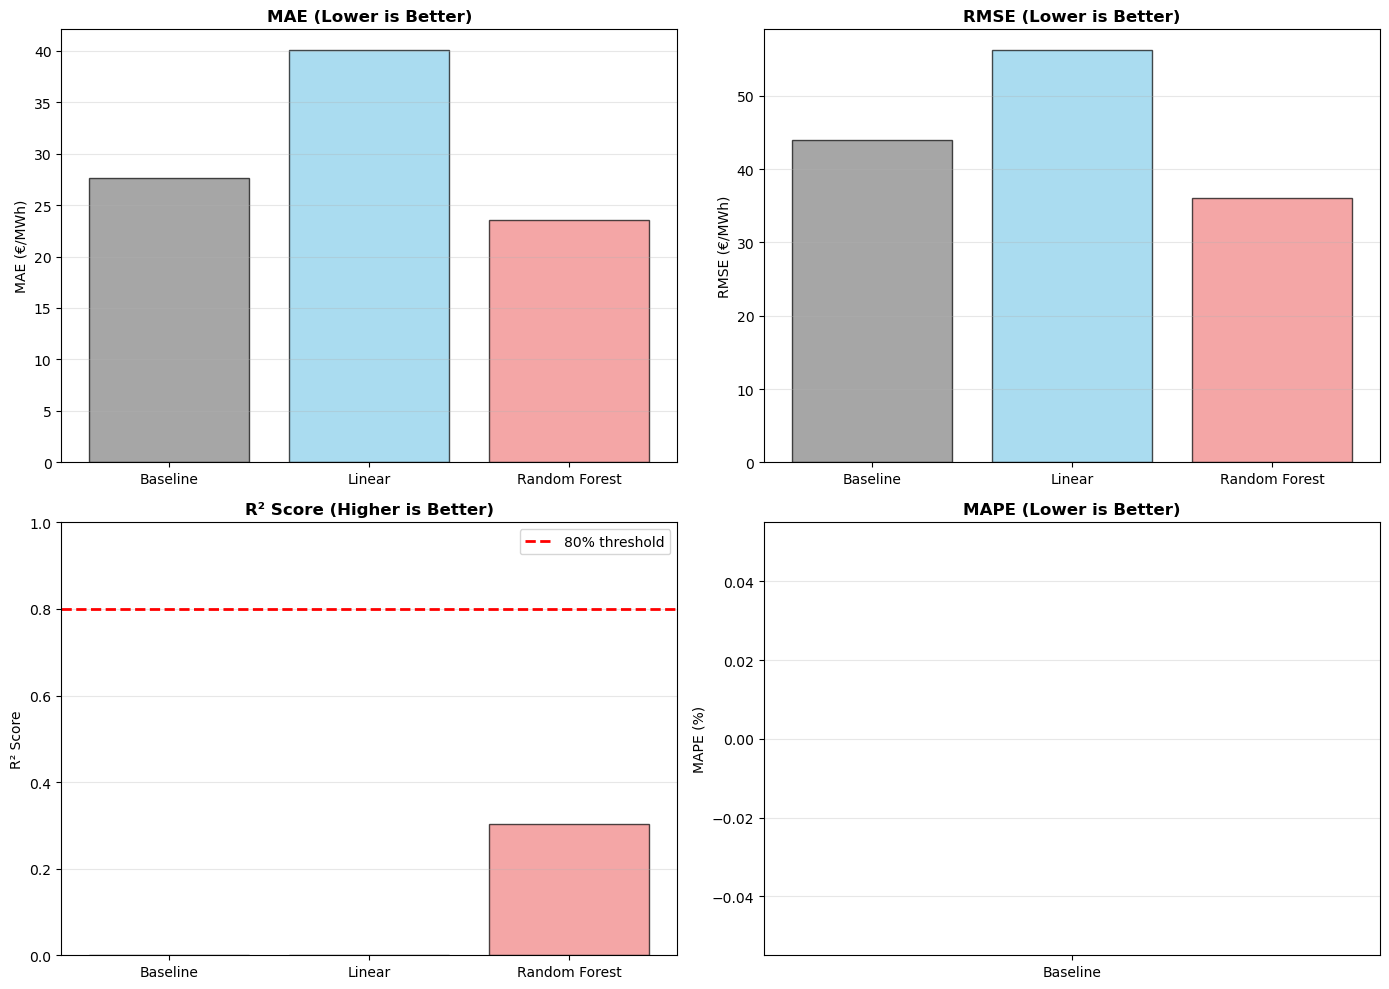

✓ Saved: plots/05_model_comparison.png

[PLOT 2] Creating predictions plot...


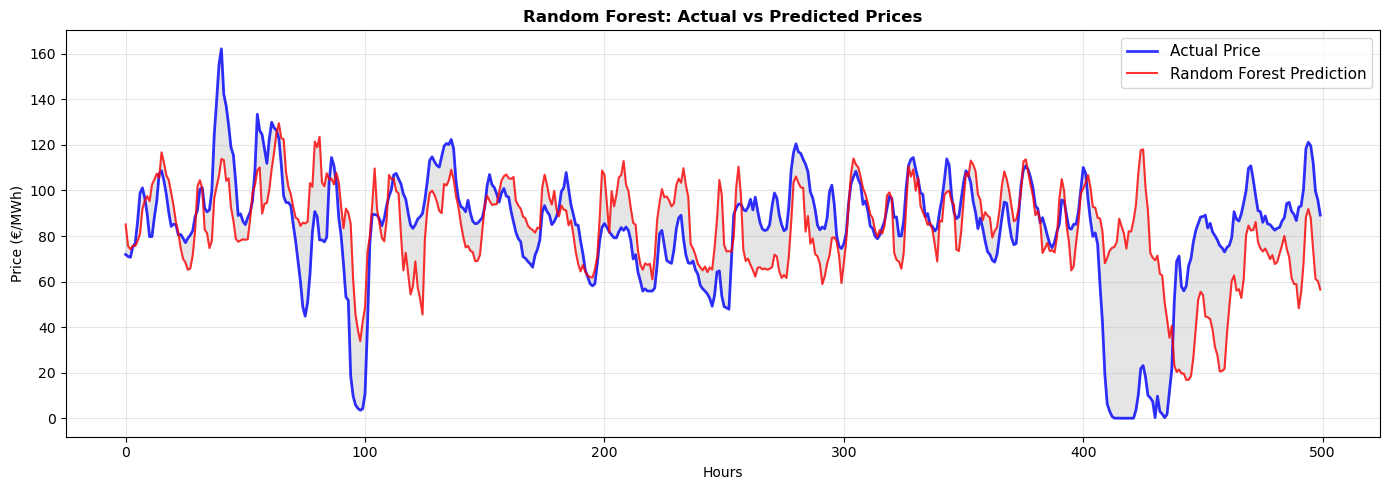

✓ Saved: plots/06_predictions_vs_actual.png

[PLOT 3] Creating residuals analysis plot...


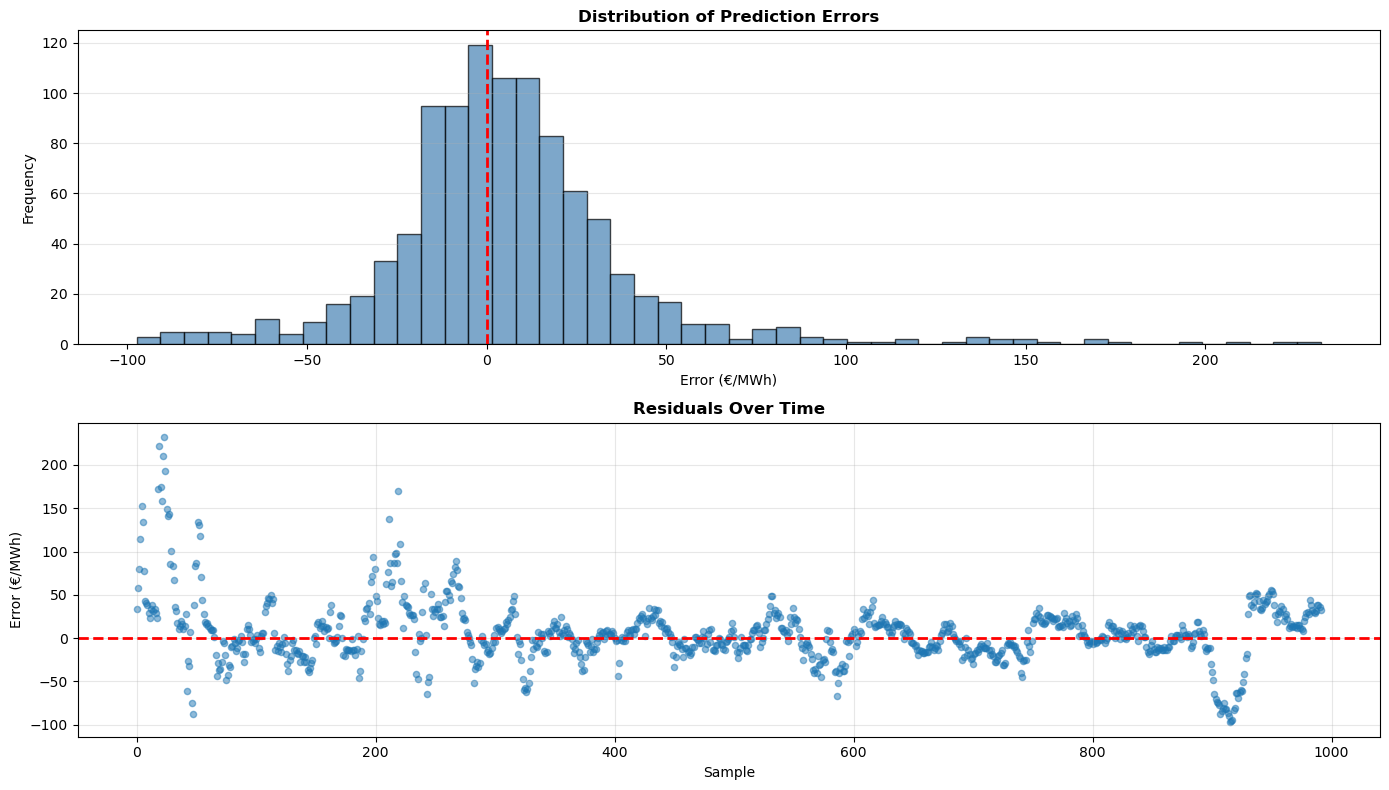

✓ Saved: plots/07_residuals_analysis.png

MODEL TRAINING COMPLETE!

✓ Best Model: Random Forest
  • MAE: €23.55

✓ Models saved to: models/
  • linear_regression.pkl
  • random_forest.pkl
  • scaler.pkl

✓ Visualizations saved to: plots/
  • 05_model_comparison.png
  • 06_predictions_vs_actual.png
  • 07_residuals_analysis.png

✓ Ready for next step: Notebook 4 (Deployment)



In [1]:
# NOTEBOOK 3: MODEL TRAINING

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("="*70)
print("NOTEBOOK 3: MODEL TRAINING & COMPARISON")
print("="*70)

# ===== LOAD FEATURES =====
print("\n[STEP 1] Loading feature dataset...")
df = pd.read_csv('data/features.csv')
print(f"✓ Loaded {len(df)} rows, {len(df.columns)} columns")

# ===== PREPARE DATA =====
print("\n[STEP 2] Preparing data...")
X = df.drop(['timestamp', 'price', 'target'], axis=1)
y = df['target']
print(f"✓ Features shape: {X.shape}")
print(f"✓ Target shape: {y.shape}")

# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Remove rows with NaN or inf
initial_rows = len(X)
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]

removed = initial_rows - len(X)
print(f"✓ Removed {removed} rows with NaN/inf")
print(f"✓ Final dataset: {len(X)} rows")

# Remove NaN
#initial_rows = len(X)
#mask = ~(X.isna().any(axis=1) | y.isna())
#X = X[mask]
#y = y[mask]
#removed = initial_rows - len(X)
#print(f"✓ Removed {removed} rows with NaN")
#print(f"✓ Final dataset: {len(X)} rows")

# ===== TRAIN-TEST SPLIT =====
print("\n[STEP 3] Splitting data (80% train, 20% test)...")
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]
print(f"✓ Train: {len(X_train)} rows")
print(f"✓ Test: {len(X_test)} rows")

# ===== SCALE FEATURES =====
print("\n[STEP 4] Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved")

# ===== MODEL 1: BASELINE =====
print("\n" + "="*70)
print("MODEL 1: BASELINE (Last Hour's Price)")
print("="*70)
print("[Training...] No training needed (baseline)")
y_pred_baseline = X_test['price_lag_1'].values
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)
mape_baseline = np.mean(np.abs((y_test - y_pred_baseline) / y_test)) * 100
print(f"✓ Baseline Results:")
print(f"  MAE:  €{mae_baseline:.2f}")
print(f"  RMSE: €{rmse_baseline:.2f}")
print(f"  R²:   {r2_baseline:.4f}")
print(f"  MAPE: {mape_baseline:.2f}%")

# ===== MODEL 2: LINEAR REGRESSION =====
print("\n" + "="*70)
print("MODEL 2: LINEAR REGRESSION")
print("="*70)
print("[Training...] Fitting Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
improvement_lr = ((mae_baseline - mae_lr) / mae_baseline) * 100
print(f"✓ Results:")
print(f"  MAE:  €{mae_lr:.2f}")
print(f"  RMSE: €{rmse_lr:.2f}")
print(f"  R²:   {r2_lr:.4f}")
print(f"  MAPE: {mape_lr:.2f}%")
print(f"  Improvement vs Baseline: {improvement_lr:.1f}%")
with open('models/linear_regression.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print(f"✓ Model saved")

# ===== MODEL 3: RANDOM FOREST =====
print("\n" + "="*70)
print("MODEL 3: RANDOM FOREST REGRESSOR")
print("="*70)
print("[Training...] Training Random Forest (may take 1-2 min)...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
improvement_rf = ((mae_baseline - mae_rf) / mae_baseline) * 100
print(f"✓ Results:")
print(f"  MAE:  €{mae_rf:.2f}")
print(f"  RMSE: €{rmse_rf:.2f}")
print(f"  R²:   {r2_rf:.4f}")
print(f"  MAPE: {mape_rf:.2f}%")
print(f"  Improvement vs Baseline: {improvement_rf:.1f}%")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nTop 5 Important Features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']:30s}: {row['importance']:.4f}")

with open('models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
feature_importance.to_csv('models/feature_importance.csv', index=False)
print(f"✓ Model saved")

# ===== MODEL 4: XGBOOST =====
print("\n" + "="*70)
print("MODEL 4: XGBOOST (Gradient Boosting)")
print("="*70)
try:
    from xgboost import XGBRegressor
    print("[Training...] Training XGBoost (may take 2-3 min)...")
    
    xgb_model = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    r2_xgb = r2_score(y_test, y_pred_xgb)
    mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
    improvement_xgb = ((mae_baseline - mae_xgb) / mae_baseline) * 100
    
    print(f"✓ Results:")
    print(f"  MAE:  €{mae_xgb:.2f}")
    print(f"  RMSE: €{rmse_xgb:.2f}")
    print(f"  R²:   {r2_xgb:.4f}")
    print(f"  MAPE: {mape_xgb:.2f}%")
    print(f"  Improvement vs Baseline: {improvement_xgb:.1f}%")
    
    with open('models/xgboost.pkl', 'wb') as f:
        pickle.dump(xgb_model, f)
    print(f"✓ Model saved")
    
    xgb_available = True
except ImportError:
    print("⚠ XGBoost not installed")
    print("  Run: pip install xgboost")
    xgb_available = False
    mae_xgb = None

# ===== MODEL COMPARISON =====
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

if xgb_available:
    comparison_data = {
        'Model': ['Baseline', 'Linear Regression', 'Random Forest', 'XGBoost'],
        'MAE': [mae_baseline, mae_lr, mae_rf, mae_xgb],
        'RMSE': [rmse_baseline, rmse_lr, rmse_rf, rmse_xgb],
        'R²': [r2_baseline, r2_lr, r2_rf, r2_xgb],
        'MAPE': [mape_baseline, mape_lr, mape_rf, mape_xgb]
    }
else:
    comparison_data = {
        'Model': ['Baseline', 'Linear Regression', 'Random Forest'],
        'MAE': [mae_baseline, mae_lr, mae_rf],
        'RMSE': [rmse_baseline, rmse_lr, rmse_rf],
        'R²': [r2_baseline, r2_lr, r2_rf],
        'MAPE': [mape_baseline, mape_lr, mape_rf]
    }

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))
comparison_df.to_csv('models/model_comparison.csv', index=False)
print(f"\n✓ Comparison saved")

# ===== PLOT 1: MODEL COMPARISON =====
print("\n[PLOT 1] Creating model comparison plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if xgb_available:
    models = ['Baseline', 'Linear', 'Random Forest', 'XGBoost']
    mae_vals = [mae_baseline, mae_lr, mae_rf, mae_xgb]
    rmse_vals = [rmse_baseline, rmse_lr, rmse_rf, rmse_xgb]
    r2_vals = [r2_baseline, r2_lr, r2_rf, r2_xgb]
    mape_vals = [mape_baseline, mape_lr, mape_rf, mape_xgb]
    colors = ['gray', 'skyblue', 'lightcoral', 'lightgreen']
else:
    models = ['Baseline', 'Linear', 'Random Forest']
    mae_vals = [mae_baseline, mae_lr, mae_rf]
    rmse_vals = [rmse_baseline, rmse_lr, rmse_rf]
    r2_vals = [r2_baseline, r2_lr, r2_rf]
    mape_vals = [mape_baseline, mape_lr, mape_rf]
    colors = ['gray', 'skyblue', 'lightcoral']

axes[0, 0].bar(models, mae_vals, color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('MAE (Lower is Better)', fontweight='bold')
axes[0, 0].set_ylabel('MAE (€/MWh)')
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].bar(models, rmse_vals, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[0, 1].set_ylabel('RMSE (€/MWh)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[1, 0].bar(models, r2_vals, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='80% threshold')
axes[1, 0].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(models, mape_vals, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('MAPE (Lower is Better)', fontweight='bold')
axes[1, 1].set_ylabel('MAPE (%)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: plots/05_model_comparison.png")

# ===== PLOT 2: PREDICTIONS VS ACTUAL =====
print("\n[PLOT 2] Creating predictions plot...")

if xgb_available:
    y_pred_best = y_pred_xgb
    model_name = 'XGBoost'
else:
    y_pred_best = y_pred_rf
    model_name = 'Random Forest'

plot_range = min(500, len(y_test))
y_actual_plot = y_test.values[-plot_range:]
y_pred_plot = y_pred_best[-plot_range:]

plt.figure(figsize=(14, 5))
plt.plot(range(plot_range), y_actual_plot, label='Actual Price', linewidth=2, color='blue', alpha=0.8)
plt.plot(range(plot_range), y_pred_plot, label=f'{model_name} Prediction', linewidth=1.5, alpha=0.8, color='red')
plt.fill_between(range(plot_range), y_actual_plot, y_pred_plot, alpha=0.2, color='gray')
plt.title(f'{model_name}: Actual vs Predicted Prices', fontsize=12, fontweight='bold')
plt.xlabel('Hours')
plt.ylabel('Price (€/MWh)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/06_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: plots/06_predictions_vs_actual.png")

# ===== PLOT 3: RESIDUALS ANALYSIS =====
print("\n[PLOT 3] Creating residuals analysis plot...")

residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Error (€/MWh)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].scatter(range(len(residuals)), residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Error (€/MWh)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/07_residuals_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: plots/07_residuals_analysis.png")

# ===== FINAL SUMMARY =====
print("\n" + "="*70)
print("MODEL TRAINING COMPLETE!")
print("="*70)

best_mae = min(mae_lr, mae_rf, mae_xgb if xgb_available else float('inf'))
best_model_name = 'Linear' if best_mae == mae_lr else ('Random Forest' if best_mae == mae_rf else 'XGBoost')

print(f"\n✓ Best Model: {best_model_name}")
print(f"  • MAE: €{best_mae:.2f}")

print(f"\n✓ Models saved to: models/")
print(f"  • linear_regression.pkl")
print(f"  • random_forest.pkl")
if xgb_available:
    print(f"  • xgboost.pkl")
print(f"  • scaler.pkl")

print(f"\n✓ Visualizations saved to: plots/")
print(f"  • 05_model_comparison.png")
print(f"  • 06_predictions_vs_actual.png")
print(f"  • 07_residuals_analysis.png")

print(f"\n✓ Ready for next step: Notebook 4 (Deployment)")
print("\n" + "="*70)